# RFI analysis of 1GHz to 1.5GHz

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd

def k(x):
    return x*1000

In [2]:
def gaussian_kernel(x, xi, h):
    return np.exp(-0.5 * ((x - xi) / h) ** 2) / (h * np.sqrt(2 * np.pi))

def epanechnikov_kernel(x, xi, h):
    u = (x - xi) / h
    kernel_value = 0.75 * (1 - u**2) * (np.abs(u) <= 1)
    return kernel_value / h

def kernel_regression(X_train, y_train, x_query, h, num_neighbors=10, x_min=0, x_max=None, kernel_type='Gaussian'):
    if x_max is None:
        x_max = X_train.max()
    
    # Only consider the nearest neighbors for the kernel regression
    X_neighbors = np.arange(x_query - num_neighbors, x_query + num_neighbors)
    X_neighbors = X_neighbors[(X_neighbors >= x_min) & (X_neighbors < x_max)]
    
    y_neighbors = y_train[X_neighbors]  # Adjust indexing for the slice
    
    # Compute the weights for the neighbors
    if kernel_type=='Gaussian':
        weights = np.array([gaussian_kernel(x_query, xi, h) for xi in X_neighbors])
    else:
        weights = np.array([epanechnikov_kernel(x_query, xi, h) for xi in X_neighbors])
    weights /= weights.sum()  # Normalize the weights
    
    # Return the weighted sum of the nearest neighbors' responses
    return np.nansum(weights * y_neighbors)

In [3]:
file = '/srv/data/drao-rfi/calibrated/RFInd-calibrated-2024-10-08T12.sigmf-data'
meta = '/srv/data/drao-rfi/calibrated/RFInd-calibrated-2024-10-08T12.sigmf-meta'
data = np.memmap(file, dtype='f4')

with open(meta) as m:
    m = json.load(m)

data = data.reshape(-1, 600000)

min_f = m['global']['antenna:low_frequency']
max_f = m['global']['antenna:high_frequency']
rate = m['global']['core:sample_rate']
period = 1/ rate
f_resolution = (max_f - min_f) / k(600)

print(f"Min Frequency: {min_f/1e6} MHz")
print(f"Max Frequency: {max_f/1e6} MHz")
print(f"Sample Rate: {rate/1e6} MHz")
print(f"Period: {period} s")
print(f"Frequency Resolution: {f_resolution/1e6} MHz")

def convert_frequency_to_index(f):
    """ Function which converts input frequency in MHz to index,
    Where index 600k = 6 GHz
    index 0 = 20 MHz

    Using inverse of
    f = i*(max_f-min_f)/k(600) + min_f
    """

    min_f = m['global']['antenna:low_frequency']
    max_f = m['global']['antenna:high_frequency']

    return int((f*1e6 - min_f)*k(600)/(max_f-min_f))

def convert_index_to_frequency(i):
    """ Function which converts input index to frequency in MHz,
    Where index 600k = 6 GHz
    index 0 = 20 MHz

    Using
    f = i*(max_f-min_f)/k(600) + min_f
    """

    min_f = m['global']['antenna:low_frequency']
    max_f = m['global']['antenna:high_frequency']   
    return (i*(max_f-min_f)/k(600) + min_f)/1e6

Min Frequency: 20.0 MHz
Max Frequency: 6000.0 MHz
Sample Rate: 1.3333333333333332e-06 MHz
Period: 0.75 s
Frequency Resolution: 0.009966666666666665 MHz


In [24]:
m

{'global': {'antenna:gain': 0.0,
  'antenna:hagl': 13.0,
  'antenna:high_frequency': 6000000000.0,
  'antenna:low_frequency': 20000000.0,
  'antenna:mobile': False,
  'antenna:model': 'Alaris OMNI-0190-04',
  'antenna:steerable': False,
  'core:author': 'nicholas.bruce@nrc-cnrc.gc.ca',
  'core:datatype': 'rf32_le',
  'core:extensions': [{'name': 'antenna',
    'optional': True,
    'version': '1.0.0'},
   {'name': 'ntia-sensor', 'optional': True, 'version': '1.0.0'}],
  'core:geolocation': {'coordinates': [49.321474, -119.620016],
   'type': 'Point'},
  'core:hw': 'RFInd',
  'core:num_channels': 600000,
  'core:sample_rate': 1.3333333333333333,
  'core:sha512': 'f6240abca35e8144016eb7db510a7bad38569a25987349fb4dc350bbc4f6b0cc1de2278b42438ce84df9f565c0628d0239241190dbcb139b42c89cc680ea81ac',
  'core:version': '1.1.0'},
 'captures': [{'core:datetime': '2024-10-08T12:00:00.250002+00:00',
   'core:sample_start': 0}],
 'annotations': [{'core:generator': 'RFInd::FileWriter',
   'core:label':

### The RFI Monitor cycles peridocially, A clean stretch from time index 500 to 1500 is used for further analysis

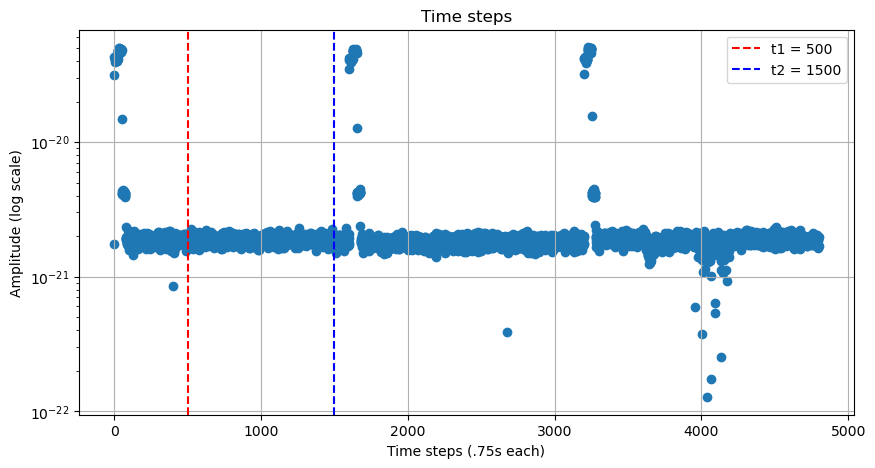

In [4]:
t1 = 500
t2 = 1500

plt.figure(figsize=(10, 5))
plt.scatter(np.arange(4800), data[0:4800, k(400)])
# for i, txt in enumerate(np.arange(180)):
#     plt.annotate(f'{txt:.2e}', (np.arange(180)[i], data[0:180, k(400)][i]), fontsize=8, rotation=45)
plt.title("Time steps")
plt.yscale('log')
plt.xlabel("Time steps (.75s each)")
plt.ylabel("Amplitude (log scale)")
plt.grid(True)
plt.axvline(x=t1, color='r', linestyle='--', label=f't1 = {t1}')
plt.axvline(x=t2, color='b', linestyle='--', label=f't2 = {t2}')
plt.legend()
plt.show()

## Large scale picture from 1000-1500 MHz range with kernel regression to fit a baseline value.

In [26]:
min_f = 1000
max_f = 1500

min_i = convert_frequency_to_index(min_f)
max_i = convert_frequency_to_index(max_f)

x_vals_i = np.arange(min_i, max_i)
x_vals_f = convert_index_to_frequency(x_vals_i)

# slice out the block we want to summarize
data_slice = data[t1:t2, min_i:max_i]
data_slice = np.where(data_slice > 1e-25, data_slice, np.nan)  # ignore non-positive values

# geometric mean (ignore non‐positive values)
geo_means = np.exp(np.log(data_slice).mean(axis=0))

# geometric std (multiplicative): exp(std(log(x))) ignoring non‐positive
log_data = np.where(data_slice > 0, np.log(data_slice), np.nan)
geo_stds  = np.exp(np.nanstd(log_data, axis=0))

compressed_data = pd.DataFrame({"index": x_vals_i, "frequency": x_vals_f, "mean": geo_means, "std": geo_stds})

i = 1
for j in range(t1, t2, 100):
    raw_trace = data[j, min_i:max_i]
    compressed_data[f'trace_{i}'] = raw_trace
    i += 1

print("Means shape:", geo_means.shape)
print("Stds shape:",  geo_stds.shape)

Means shape: (50167,)
Stds shape: (50167,)


/usr/local/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [27]:
compressed_data.head()

,index,frequency,mean,std,trace_1,trace_2,trace_3,trace_4,trace_5,trace_6,trace_7,trace_8,trace_9,trace_10
0,98327,999.992433,2.562481e-21,1.058813,2.544566e-21,2.587080e-21,2.345059e-21,2.685980e-21,2.414260e-21,2.719590e-21,2.335451e-21,2.558203e-21,2.742835e-21,2.444180e-21
1,98328,1000.002400,2.597825e-21,1.056187,2.576994e-21,2.627191e-21,2.575326e-21,2.604295e-21,2.448726e-21,2.562568e-21,2.523265e-21,2.533717e-21,2.648458e-21,2.791021e-21
2,98329,1000.012367,2.889837e-21,1.055346,2.831472e-21,3.202285e-21,2.522150e-21,2.691775e-21,2.912867e-21,3.039584e-21,2.890836e-21,2.752864e-21,3.001745e-21,2.766441e-21
3,98330,1000.022333,2.544092e-21,1.058800,2.547318e-21,2.721499e-21,2.434621e-21,2.484078e-21,2.595345e-21,2.397754e-21,2.924218e-21,2.472746e-21,2.585837e-21,2.423670e-21
4,98331,1000.032300,2.535991e-21,1.057067,2.509959e-21,2.789018e-21,2.495191e-21,2.424299e-21,2.540680e-21,2.413481e-21,2.488192e-21,2.370051e-21,2.648837e-21,2.485272e-21


<Figure size 1000x500 with 0 Axes>

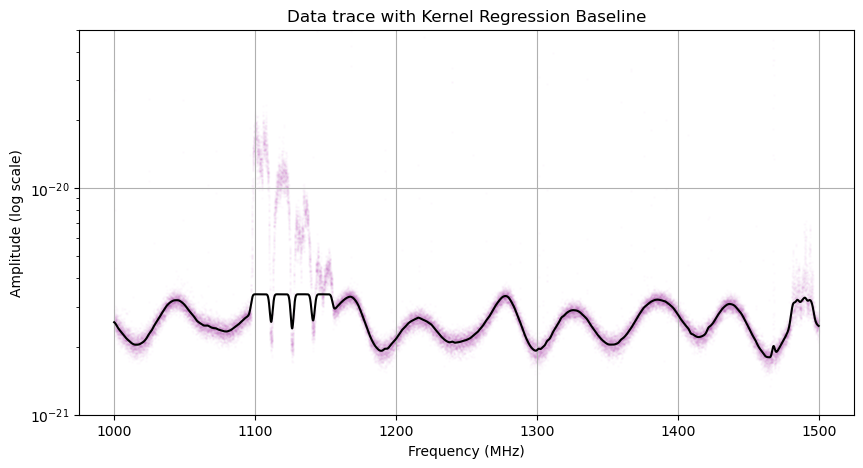

In [28]:
plt.figure(figsize=(10,5))

min_cutoff = 1.2 * 10**(-21)
max_cutoff = 3.4 * 10**(-21)

X_train = np.arange(0, len(compressed_data))
y_train = np.clip(compressed_data["mean"], min_cutoff, max_cutoff)
x_predictions = X_train
baseline = np.array([kernel_regression(X_train, y_train, X, h=90, num_neighbors=300) for X in x_predictions])
compressed_data["baseline"] = baseline

# plot mean and ±2σ
frequency_range = compressed_data["frequency"]

plt.figure(figsize=(10,5))

# plot a few raw traces
for j in range(1, 2):
    plt.scatter(
        frequency_range, 
        compressed_data[f'trace_{j}'],
        c='m', s=1, alpha=0.01, 
        label='data' if j==t1 else None
    )

plt.plot(
    frequency_range, 
    baseline,
    label='mean',
    color='black'
)

plt.ylim(1e-21, 5e-20)

plt.yscale('log')
plt.title("Data trace with Kernel Regression Baseline")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude (log scale)")
plt.grid(True)


In [ ]:
H_transitions = {
    "H186alpha": 1013.76766452,
    "H185alpha": 1030.25153147,
    "H184alpha": 1047.09471537,
    "H183alpha": 1064.30706038,
    "H182alpha": 1081.89873607,
    "H181alpha": 1099.88025005,
    "H180alpha": 1118.26246118,
    "H179alpha": 1137.05659327,
    "H178alpha": 1156.27424957,
    "H177alpha": 1175.92742772,
    "H176alpha": 1196.02853557,
    "H175alpha": 1216.59040757,
    "H174alpha": 1237.626322,
    "H173alpha": 1259.150019,
    "H172alpha": 1281.1757194,
    "H171alpha": 1303.71814445,
    "H170alpha": 1326.7925365,
    "H169alpha": 1350.41468066,
    "H168alpha": 1374.60092745,
    "H167alpha": 1399.36821658,
    "H166alpha": 1424.73410189,
    "H165alpha": 1450.71677746,
    "H164alpha": 1477.33510502,
}

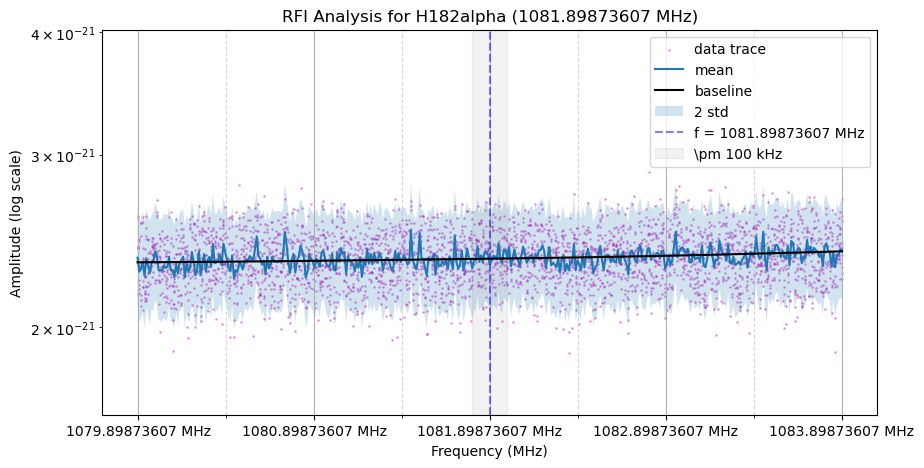

In [ ]:

for transition_name, frequency in H_transitions.items():
    f = frequency
    close_range = f - 0.1, f + 0.1
    long_range = f - 2, f + 2

    closest_row = (compressed_data['frequency'] - f).abs().idxmin()
    close_min_row = (compressed_data['frequency'] - close_range[0]).abs().idxmin()
    close_max_row = (compressed_data['frequency'] - close_range[1]).abs().idxmin()
    long_min_row = (compressed_data['frequency'] - long_range[0]).abs().idxmin()
    long_max_row = (compressed_data['frequency'] - long_range[1]).abs().idxmin()

    close_id_range = range(close_min_row, close_max_row + 1)
    long_id_range = range(long_min_row, long_max_row + 1)

    frequency_range = compressed_data.loc[long_id_range, 'frequency']
    baseline = compressed_data.loc[long_id_range, 'baseline'] 
    geo_means = compressed_data.loc[long_id_range, 'mean']
    geo_stds = compressed_data.loc[long_id_range, 'std']

    y_min = np.min(compressed_data.loc[close_id_range][["baseline", "mean", "trace_1", "trace_2", "trace_3"]])*0.8
    y_max = np.max(compressed_data.loc[close_id_range][["baseline", "mean", "trace_1", "trace_2", "trace_3"]])*1.5

    plt.figure(figsize=(10,5))

    # plot a few raw traces
    for j in range(1, 10):
        plt.scatter(
            frequency_range, 
            compressed_data.loc[long_id_range, f'trace_{j}'],
            c='m', s=1, alpha=0.3, 
            label='data trace' if j==1 else None
        )

    # plot mean and ±2σ
    plt.plot(
        frequency_range, 
        geo_means,
        label='mean'
    )

    plt.plot(
        frequency_range, 
        baseline,
        label='baseline',
        color='black'
    )

    plt.fill_between(frequency_range,
                    geo_means/(geo_stds**2),
                    geo_means*(geo_stds**2),
                    alpha=0.2, label='2 std')

    plt.axvline(
        x=f, color='b', alpha=0.5, linestyle='--', label=f'f = {f} MHz')
    plt.axvspan(
        compressed_data.loc[close_min_row, "frequency"],
        compressed_data.loc[close_max_row, "frequency"],
        color='grey', alpha=0.1, label='\pm 100 kHz')


    # Set logarithmic scale for y-axis
    plt.yscale('log')

    # Set major ticks on x-axis at every 1 unit with MHz labels
    major_ticks = np.arange(long_range[0], long_range[1] + 1, 1)
    plt.xticks(ticks=major_ticks, labels=[f"{x} MHz" for x in major_ticks])

    # Enable minor ticks for both axes
    plt.minorticks_on()

    # Set minor ticks on x-axis at every 0.5 units
    minor_ticks = np.arange(long_range[0], long_range[1] + 0.5, 0.5)
    plt.gca().set_xticks(minor_ticks, minor=True)

    # Enable grid for major ticks on x-axis
    plt.grid(visible=True, which='minor', axis='x', linestyle='--', alpha=0.5)
    plt.grid(visible=True, which='major', axis='x')

    plt.legend()
    plt.title("RFI Analysis for " + transition_name + f" ({f} MHz)")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Amplitude (log scale)")

    plt.ylim(y_min, y_max)

    plt.savefig(f'rrl_images/{transition_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
